⚠️ No CSV found — generating synthetic data.
Dataset: synthetic
Train: 1400 | Val: 300 | Test: 300

🔧 Training model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1464 - mae: 0.3113 - val_loss: 0.0135 - val_mae: 0.0959
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0335 - mae: 0.1396 - val_loss: 0.0130 - val_mae: 0.0948
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0277 - mae: 0.1269 - val_loss: 0.0117 - val_mae: 0.0896
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0255 - mae: 0.1219 - val_loss: 0.0117 - val_mae: 0.0900
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0230 - mae: 0.1167 - val_loss: 0.0122 - val_mae: 0.0918
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0227 - mae: 0.1170 - val_loss: 0.0101 - val_mae: 0.0833
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0219 - mae: 0.1145 - val_loss: 0.0144 - val_mae: 0.1006
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0186 - mae: 0.1062 - val_loss: 0.0085 - val_mae: 0.0767
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.017

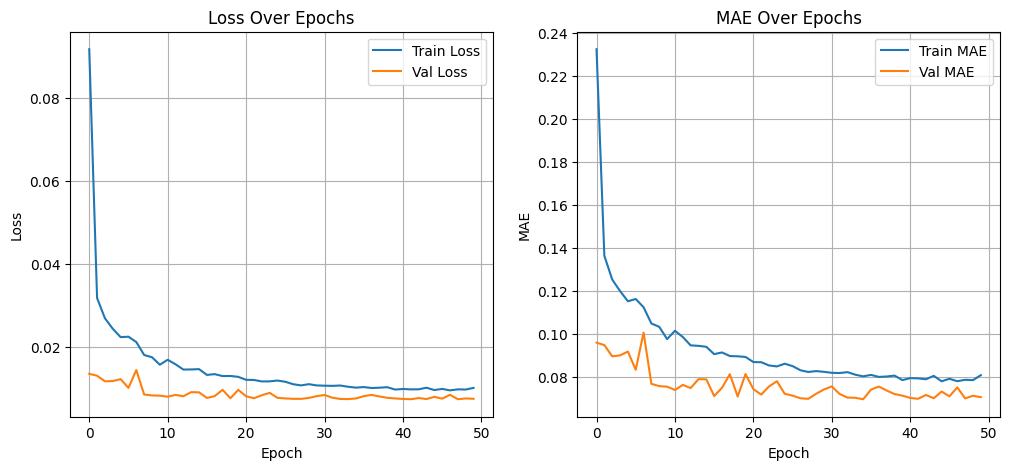


🔮 Sample Predictions:


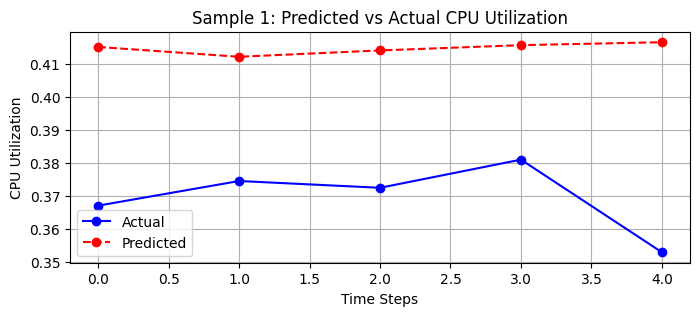

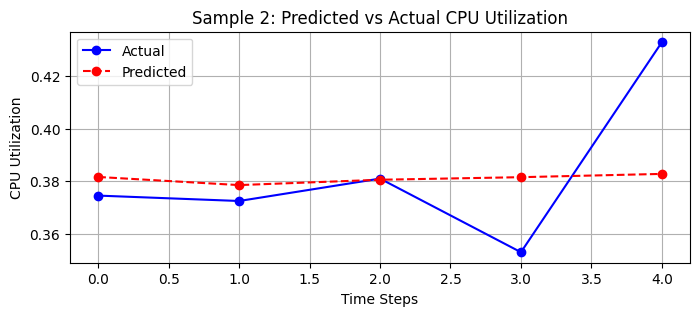

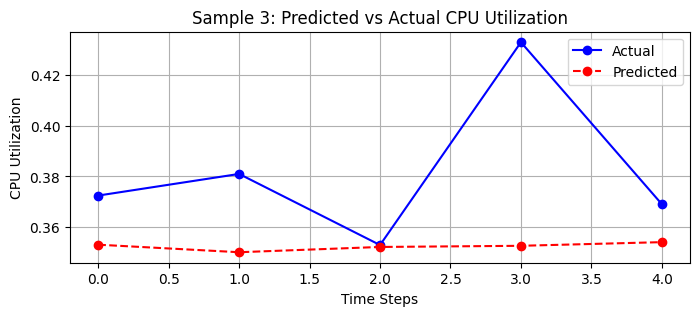


🧠 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,017 (375.07 KB)

 Trainable params: 32,005 (125.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,012 (250.05 KB)

In [ ]:
# ==============================
# HDRL-LF: LSTM Load Forecasting (Colab Version)
# Author: HDRL-LF Framework
# ==============================

# 📦 Install dependencies (only for Colab)
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn joblib

# ==============================
# 🔧 Import Libraries
# ==============================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, re, glob, os

# ==============================
# ⚙️ LSTM Forecasting Class
# ==============================
class LoadForecaster:
    def __init__(self, seq_len=10, hidden_units=50, dropout=0.2, lr=0.001, pred_horizon=5):
        self.seq_len = seq_len
        self.hidden_units = hidden_units
        self.dropout = dropout
        self.lr = lr
        self.pred_horizon = pred_horizon
        self.model = None
        self.scaler = MinMaxScaler()
        self.trained = False
        self.history = None

    def _create_model(self, input_shape):
        model = Sequential([
            LSTM(self.hidden_units, return_sequences=True, input_shape=input_shape),
            Dropout(self.dropout),
            LSTM(self.hidden_units, return_sequences=False),
            Dropout(self.dropout),
            Dense(self.hidden_units // 2, activation='relu'),
            Dropout(self.dropout),
            Dense(self.pred_horizon, activation='linear')
        ])
        model.compile(optimizer=Adam(learning_rate=self.lr), loss='mse', metrics=['mae'])
        return model

    def prepare_data(self, data):
        scaled = self.scaler.fit_transform(data.reshape(-1, 1)).flatten()
        X, y = [], []
        for i in range(self.seq_len, len(scaled) - self.pred_horizon + 1):
            X.append(scaled[i-self.seq_len:i])
            y.append(scaled[i:i+self.pred_horizon])
        return np.array(X), np.array(y)

    def train(self, train_data, val_data=None, epochs=50, batch_size=32):
        X_train, y_train = self.prepare_data(train_data)
        self.model = self._create_model((self.seq_len, 1))
        val_split = None
        if val_data is not None:
            X_val, y_val = self.prepare_data(val_data)
            val_split = (X_val, y_val)
        history = self.model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                                 validation_data=val_split, verbose=1, shuffle=True)
        self.trained = True
        self.history = history.history
        return history.history

    def evaluate(self, test_data):
        X_test, y_test = self.prepare_data(test_data)
        preds = self.model.predict(X_test, verbose=0)
        mse = mean_squared_error(y_test.flatten(), preds.flatten())
        mae = mean_absolute_error(y_test.flatten(), preds.flatten())
        rmse = np.sqrt(mse)
        eps = 1e-8
        mape = np.mean(np.abs((y_test.flatten() - preds.flatten()) /
                              np.maximum(np.abs(y_test.flatten()), eps))) * 100
        return {"MSE": mse, "MAE": mae, "RMSE": rmse, "MAPE": mape}

    def plot_history(self):
        if not self.history: return
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(self.history['loss'], label='Train Loss')
        if 'val_loss' in self.history: plt.plot(self.history['val_loss'], label='Val Loss')
        plt.legend(); plt.title('Loss Over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)

        plt.subplot(1,2,2)
        plt.plot(self.history['mae'], label='Train MAE')
        if 'val_mae' in self.history: plt.plot(self.history['val_mae'], label='Val MAE')
        plt.legend(); plt.title('MAE Over Epochs'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.grid(True)
        plt.show()

    def plot_predictions(self, test_data, num_samples=3):
        X_test, y_test = self.prepare_data(test_data)
        preds = self.model.predict(X_test, verbose=0)
        for i in range(num_samples):
            plt.figure(figsize=(8,3))
            plt.plot(y_test[i], 'bo-', label='Actual')
            plt.plot(preds[i], 'ro--', label='Predicted')
            plt.title(f'Sample {i+1}: Predicted vs Actual CPU Utilization')
            plt.xlabel('Time Steps'); plt.ylabel('CPU Utilization'); plt.legend(); plt.grid(True)
            plt.show()

# ==============================
# 📂 Load Dataset (Auto Detection)
# ==============================
def detect_cpu_column(df):
    for col in df.columns:
        if re.search('cpu', col.lower()) or re.search('util', col.lower()):
            return col
    return df.columns[0]

def load_dataset():
    files = glob.glob("*.csv")
    if not files:
        print("⚠️ No CSV found — generating synthetic data.")
        t = np.linspace(0, 10, 2000)
        data = 0.4 + 0.2*np.sin(2*np.pi*t) + 0.05*np.random.randn(len(t))
        return data, "synthetic"
    path = files[0]
    print(f"📁 Found dataset: {path}")
    df = pd.read_csv(path)
    cpu_col = detect_cpu_column(df)
    data = pd.to_numeric(df[cpu_col].fillna(method='ffill'), errors='coerce').dropna().values
    if data.max() > 1: data = data / data.max()
    return data, os.path.basename(path).split('.')[0]

# ==============================
# 🚀 Run the Complete Pipeline
# ==============================
data, name = load_dataset()

# Split data
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))
train_data, val_data, test_data = data[:train_size], data[train_size:train_size+val_size], data[train_size+val_size:]

print(f"Dataset: {name}")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# Initialize and train model
forecaster = LoadForecaster(seq_len=10, hidden_units=50, pred_horizon=5)
print("\n🔧 Training model...")
forecaster.train(train_data, val_data=val_data, epochs=50, batch_size=32)

# Evaluate performance
print("\n📊 Evaluating model...")
metrics = forecaster.evaluate(test_data)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

# Plot results
print("\n📈 Training Performance:")
forecaster.plot_history()

print("\n🔮 Sample Predictions:")
forecaster.plot_predictions(test_data, num_samples=3)

# Show model summary
print("\n🧠 Model Summary:")
forecaster.model.summary()
